# Эксперименты и графики для одного алгоритма слепой деконволюции

Ноутбук для прогона конкретного алгоритма на тестовых датасетах и построения индивидуальных графиков.

**Инструкция по использованию:**
1. **Ячейка 2 (Настройка)** — задать алгоритм, параметры, пути к папкам
2. **Ячейки 3–4 (Датасет)** — настройка датасета + прогон. Копировать эту пару для каждого нового датасета
3. **Последняя ячейка** — финальная сводка по всем датасетам для данного алгоритма

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 1. Общая настройка ноутбука: алгоритм, пути, параметры
# ══════════════════════════════════════════════════════════════════════════════
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from typing import Optional, Dict, List, Tuple
import visualisation as vis  # <-- все графики и TeX-генерация


# ── Автоопределение корня проекта ────────────────────────────────────────────
# Работает независимо от того, где лежит ноутбук: ищем pyproject.toml или src/
_nb_dir = Path(os.path.abspath("")).resolve()
PROJECT_ROOT = _nb_dir
for _p in [_nb_dir] + list(_nb_dir.parents):
    if (_p / "pyproject.toml").exists() or (_p / "src").is_dir():
        PROJECT_ROOT = _p
        break

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)



# ── Настраиваемые параметры ──────────────────────────────────────────────────
ALGORITHM_LABEL = "PMP"   # <-- Менять для каждого алгоритма

# DATASETS_ROOT = PROJECT_ROOT / "validate_images"
DATASETS_ROOT = PROJECT_ROOT / "images" / "compare_data"
RESULTS_ROOT  = PROJECT_ROOT / "presentation_graphics"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
ALG_RESULTS_DIR = RESULTS_ROOT / ALGORITHM_LABEL.replace(" ", "_")
ALG_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Параллелизация ───────────────────────────────────────────────────────────
NUM_WORKERS = 6  # Число параллельных процессов (1 = последовательно)

# --- Алгоритм: модуль / класс / параметры (для параллельного воркера) ---
ALG_MODULE = "src.blinddeconv.algorithms.blind_deconvolution.our_company.patch_wise_minimum_pixels_prior.pmp_cython_pyd.pmp"
ALG_CLASS = "PMP_BD"
ALG_KERNEL_PARAM = "kernel_size"  # имя аргумента размера ядра в конструкторе
ALG_KWARGS = {
    'kernel_size': 51, 
    'denoise_eps': 0.006, 
    'denoise_radius': 2,
    'lambda_tv': 0.005, 
    'lambda_l0': 0.002, 
    'grad_smooth_sigma': 0.285, 
    'ensemble_denoise': True,
    'impulse_preprocess': 'auto',
    'noise_estimation': 'pca',
    # 'act_params': 'auto',
    'preprocess': 'bm3d',
    'blind_denoise': 'guided',
    'pre_nonblind': 'bm3d',
             
}
from src.blinddeconv.algorithms.blind_deconvolution.our_company.patch_wise_minimum_pixels_prior.pmp_cython_pyd.pmp import PMP_BD

def create_algorithm(kernel_shape=(51, 51)):
    """Создаёт экземпляр алгоритма (для интерактивного использования)."""
    kw = dict(ALG_KWARGS)
    kw[ALG_KERNEL_PARAM] = kernel_shape
    return PMP_BD(**kw)

# def create_algorithm(kernel_shape=(31, 31)):
#     """Создаёт экземпляр алгоритма (для интерактивного использования)."""
#     alg = 
#     return alg

# ── Утилиты ──────────────────────────────────────────────────────────────────

def parse_distorted_name(filename: str) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) >= 2:
        return parts[0], parts[1], "_".join(parts[2:]) if len(parts) > 2 else ""
    return stem, None, None

def find_kernel_for_image(kernel_dir: Path, kernel_name: str) -> Optional[Path]:
    if not kernel_dir.exists():
        return None
    for f in kernel_dir.iterdir():
        if f.is_file() and kernel_name in f.stem:
            return f
    return None

def error_ratio_nonblind(original, blurred, true_kernel, est_kernel) -> float:
    """error ratio = MSE(Wiener с est_kernel) / MSE(Wiener с true_kernel)."""
    from numpy.fft import fft2, ifft2
    h, w = blurred.shape[:2]
    reg = 1e-3
    def _wr(y, k):
        K = fft2(k, s=(h, w)); Y = fft2(y, s=(h, w))
        return np.real(ifft2(np.conj(K) * Y / (np.abs(K)**2 + reg)))
    x_true = _wr(blurred, true_kernel)
    x_est  = _wr(blurred, est_kernel)
    orig = original.astype(np.float64)
    mse_true = np.mean((orig - x_true)**2)
    mse_est  = np.mean((orig - x_est)**2)
    return mse_est / mse_true if mse_true > 1e-12 else 1.0

# ── matplotlib настройки ─────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120,
                     'savefig.dpi': 150, 'savefig.bbox': 'tight'})

ALL_DATASET_RESULTS: List[Dict] = []

print(f"Алгоритм: {ALGORITHM_LABEL}")
print(f"Папка наборов данных: {DATASETS_ROOT}")
print(f"Папка результатов: {ALG_RESULTS_DIR}")

Алгоритм: PMP
Папка наборов данных: D:\for_proga\franework_deconvolution\framework (9)\images\compare_data
Папка результатов: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "Grid_Test"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_filters"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: Grid_Test
  Искажённые: True  |  Оригиналы: True  |  GT ядра: True
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\Grid_Test


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
# Если это датасет для замеров сложности, делаем 5 прогонов
# runs = 5 if DATASET_NAME in["Complexity_Test", "Grid_Test"] else 1
runs = 5 if DATASET_NAME in["Complexity_Test"] else 1


tasks =[]
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
        'num_runs': runs  # <--- ПЕРЕДАЕМ КОЛИЧЕСТВО ПРОГОНОВ
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Запуск генерации красивых картинок 2x4
vis.save_complex_plots(
    df=df_results, 
    dist_dir=DIST_DIR, 
    save_dir=DS_RESULT_DIR / "complex_plots", 
    alg_label=ALGORITHM_LABEL
)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 50 искажённых изображений  |  Воркеров: 6

✓ airplane_linear_impulse.png  PSNR=21.94  ER=1.27  t=24.1с
✓ boat_dendric_gaussian.png  PSNR=17.05  ER=2.15  t=25.3с
✓ airplane_defocus_.png  PSNR=22.82  ER=0.98  t=30.6с
✓ boat_moon_gaussian.png  PSNR=17.26  ER=0.93  t=37.9с
✓ airplane_heliod_gaussian.png  PSNR=18.33  ER=1.04  t=39.8с
✓ boat_comet_gaussian.png  PSNR=18.14  ER=1.95  t=41.6с
✓ boat_wspiral_.png  PSNR=19.50  ER=1.30  t=35.8с
✓ boy_hookdefocus_brown.png  PSNR=18.22  ER=1.19  t=36.0с
✓ bridge_dendric_.png  PSNR=18.73  ER=1.11  t=23.3с
✓ boy_linear_poisson.png  PSNR=27.24  ER=1.22  t=40.5с
✓ boy_spiral_.png  PSNR=18.95  ER=0.98  t=35.3с
✓ bridge_comet_brown.png  PSNR=19.12  ER=1.36  t=37.0с
✓ cameraman_linear_.png  PSNR=22.57  ER=1.32  t=19.5с
✓ bridge_largemation_.png  PSNR=23.03  ER=1.09  t=32.2с
✓ bridge_wspiral_brown.png  PSNR=19.47  ER=1.18  t=44.5с
✓ cameraman_spiral_impulse.png  PSNR=18.08  ER=0.99  t=35.2с
✓ cameraman_defocus_poisson.png  PSNR=23.25  ER=1.26  t=44.

,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,image_megapixels,time_sec,runs_count,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,Grid_Test,airplane_linear_impulse.png,airplane,linear,impulse,"(11, 11)",0.066,24.093,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,21.9446,0.7340,19.1471,0.4986,1.2747
1,Grid_Test,boat_dendric_gaussian.png,boat,dendric,gaussian,"(15, 15)",0.066,25.315,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,17.0473,0.4022,18.3803,0.3072,2.1542
2,Grid_Test,airplane_defocus_.png,airplane,defocus,,"(19, 19)",0.066,30.554,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,22.8211,0.7577,22.3396,0.7369,0.9803
3,Grid_Test,boat_moon_gaussian.png,boat,moon,gaussian,"(21, 21)",0.066,37.899,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,17.2629,0.3155,17.5489,0.2818,0.9339
4,Grid_Test,airplane_heliod_gaussian.png,airplane,heliod,gaussian,"(31, 31)",0.066,39.825,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,18.3290,0.5251,17.5145,0.3800,1.0377
5,Grid_Test,boat_comet_gaussian.png,boat,comet,gaussian,"(35, 35)",0.066,41.580,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,18.1412,0.4000,17.9269,0.3362,1.9488
6,Grid_Test,boat_wspiral_.png,boat,wspiral,,"(31, 31)",0.066,35.840,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,19.5042,0.4744,18.0720,0.3861,1.2988
7,Grid_Test,boy_hookdefocus_brown.png,boy,hookdefocus,brown,"(29, 29)",0.065,36.043,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,18.2203,0.3995,19.9749,0.4680,1.1891
8,Grid_Test,bridge_dendric_.png,bridge,dendric,,"(15, 15)",0.065,23.324,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,18.7286,0.4114,19.3336,0.3758,1.1145
9,Grid_Test,boy_linear_poisson.png,boy,linear,poisson,"(11, 11)",0.065,40.458,1,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,27.2425,0.8182,26.5987,0.7673,1.2206


  Генерация комплексных изображений (50 шт.). Пожалуйста, подождите...
  Готово! Сохранено 50 изображений в: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\Grid_Test\complex_plots


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "Complexity_Test"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_filters"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: Complexity_Test
  Искажённые: True  |  Оригиналы: True  |  GT ядра: True
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\Complexity_Test


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
# Если это датасет для замеров сложности, делаем 5 прогонов
runs = 5 if DATASET_NAME in["Complexity_Test", "Grid_Test"] else 1

tasks =[]
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
        'num_runs': runs  # <--- ПЕРЕДАЕМ КОЛИЧЕСТВО ПРОГОНОВ
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Запуск генерации красивых картинок 2x4
vis.save_complex_plots(
    df=df_results, 
    dist_dir=DIST_DIR, 
    save_dir=DS_RESULT_DIR / "complex_plots", 
    alg_label=ALGORITHM_LABEL
)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 2 искажённых изображений  |  Воркеров: 6

✓ boy_hookdefocus_kernel_gaussian.png  PSNR=19.61  ER=1.24  t=11.4с
✓ barbara_hookdefocus_kernel_gaussian.png  PSNR=20.29  ER=1.18  t=47.2с

────────────────────────────────────────────────────────────
Обработано: 2/2  |  CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\Complexity_Test\results_PMP_Complexity_Test.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,image_megapixels,time_sec,runs_count,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,Complexity_Test,boy_hookdefocus_kernel_gaussian.png,boy,hookdefocus,kernel_gaussian,"(29, 29)",0.065,11.357,5,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,19.6134,0.4951,19.9327,0.4193,1.2393
1,Complexity_Test,barbara_hookdefocus_kernel_gaussian.png,barbara,hookdefocus,kernel_gaussian,"(29, 29)",0.262,47.208,5,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,20.2867,0.4982,19.9949,0.3983,1.1767


  Генерация комплексных изображений (2 шт.). Пожалуйста, подождите...
  Готово! Сохранено 2 изображений в: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\Complexity_Test\complex_plots


## Финальная сводка: графики и TeX для одного алгоритма

Эта ячейка строит все индивидуальные графики по накопленным данным из `ALL_DATASET_RESULTS`.

Графики:
- 4. PSNR/SSIM в зависимости от итераций (если доступно)
- 5. Сходимость ядра (если доступно)
- 6. Гистограмма распределения error ratio
- 7. Зависимость от шума (если в именах файлов есть информация)
- 8. Зависимость от размера ядра
- 2. Success Rate vs Error Ratio (если есть GT ядра)

Всего обработано изображений: 52



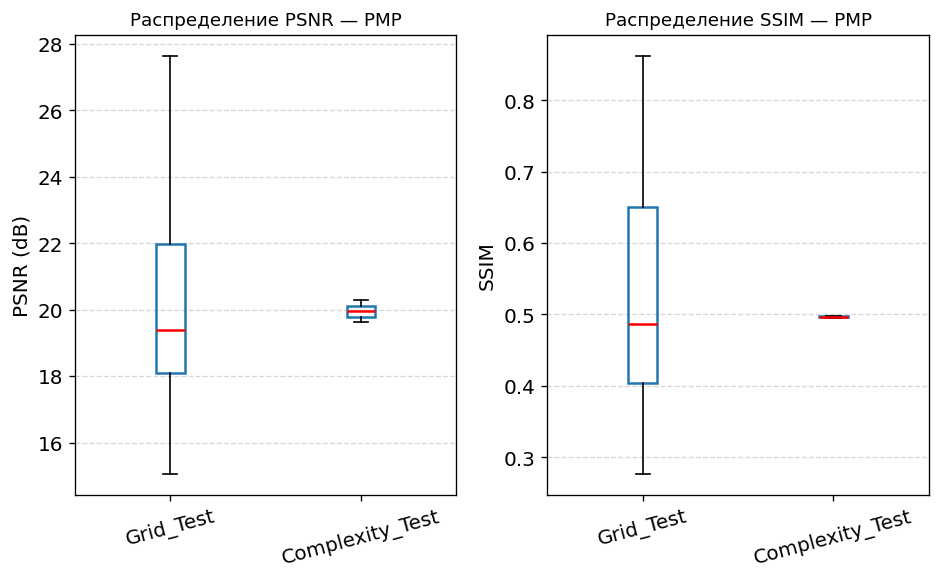

  Генерация профилей ядер (52 шт.). Пожалуйста, подождите...
Профили ядер сохранены в: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\kernel_profiles


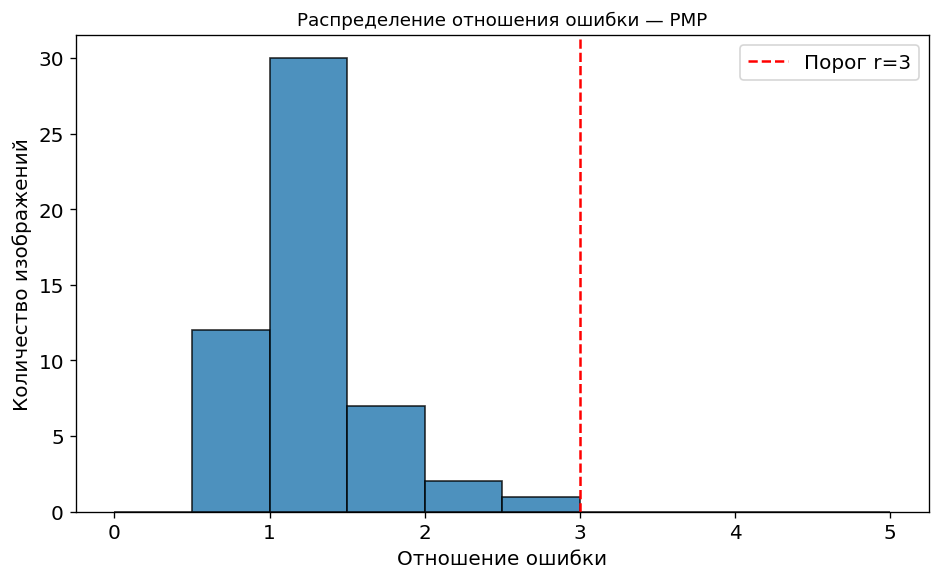

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\tex\error_ratio_histogram.tex


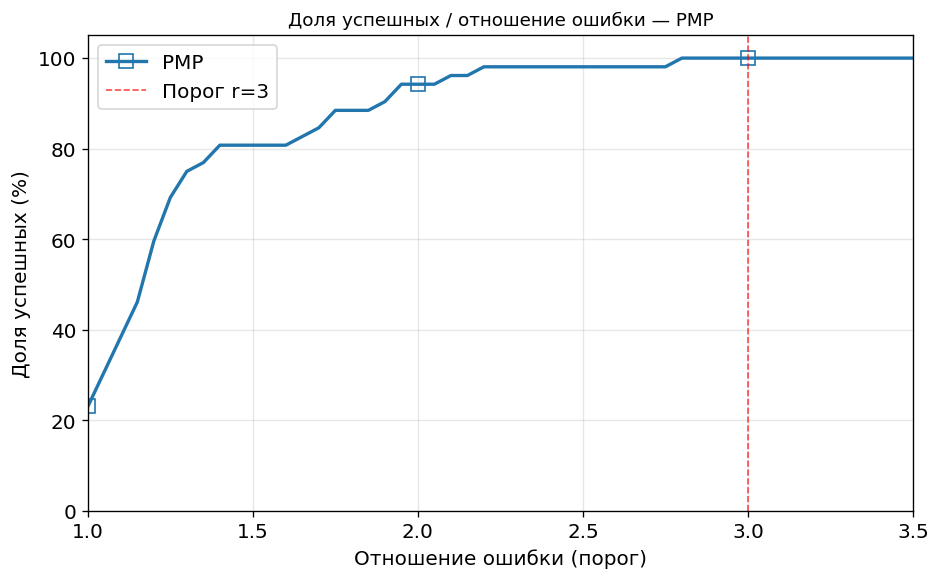

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\tex\success_rate.tex


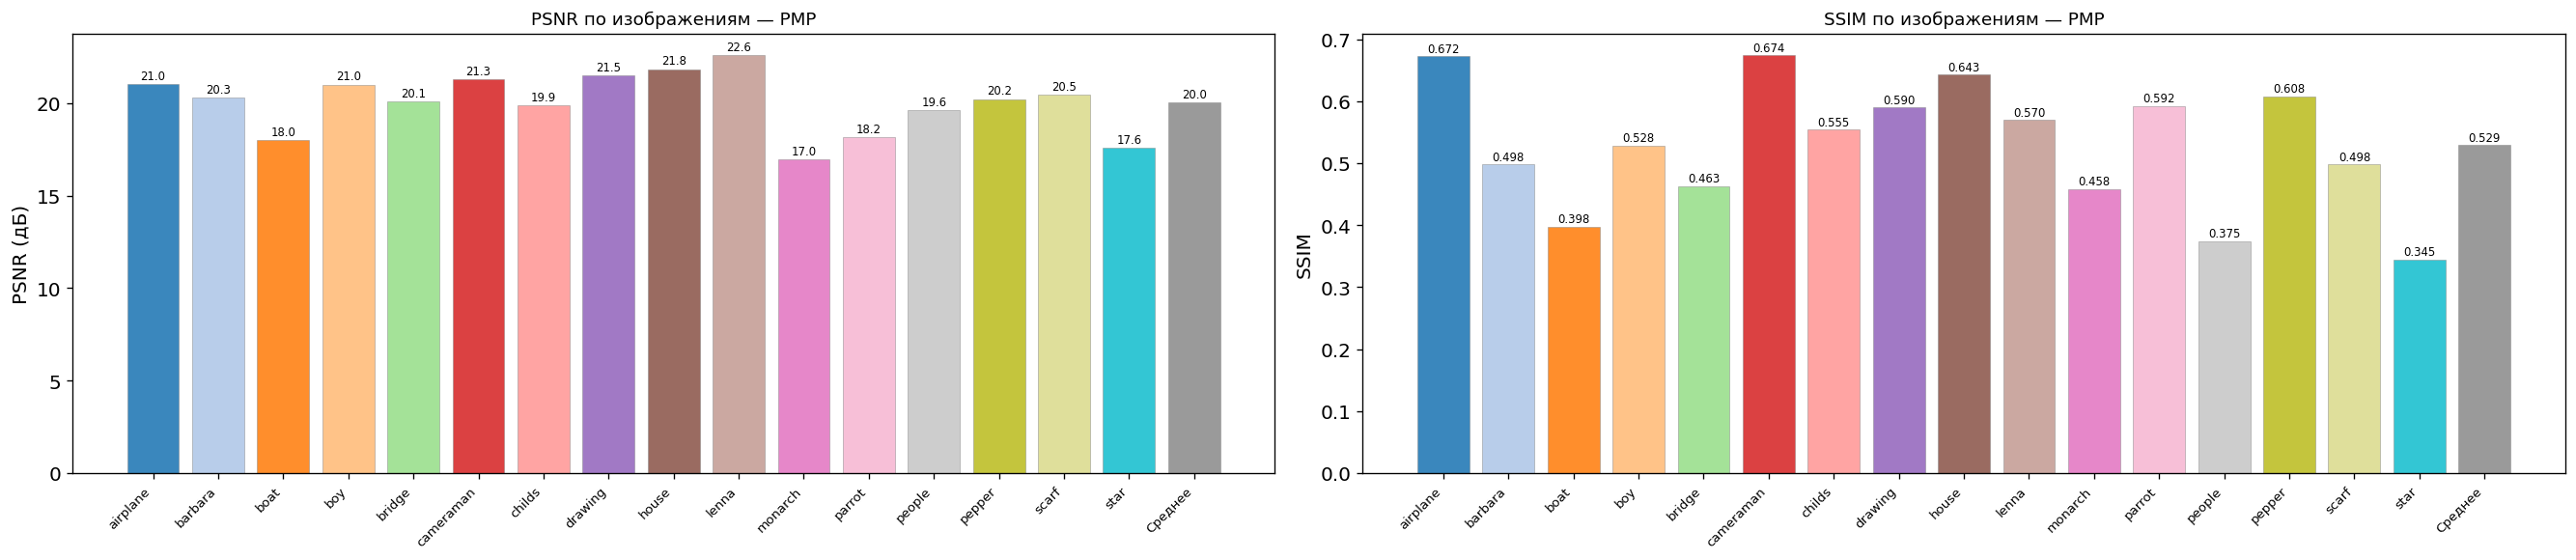

2026-04-18 18:20:33,886 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-18 18:20:33,888 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-18 18:20:33,893 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-18 18:20:33,893 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\tex\psnr_ssim_bar.tex


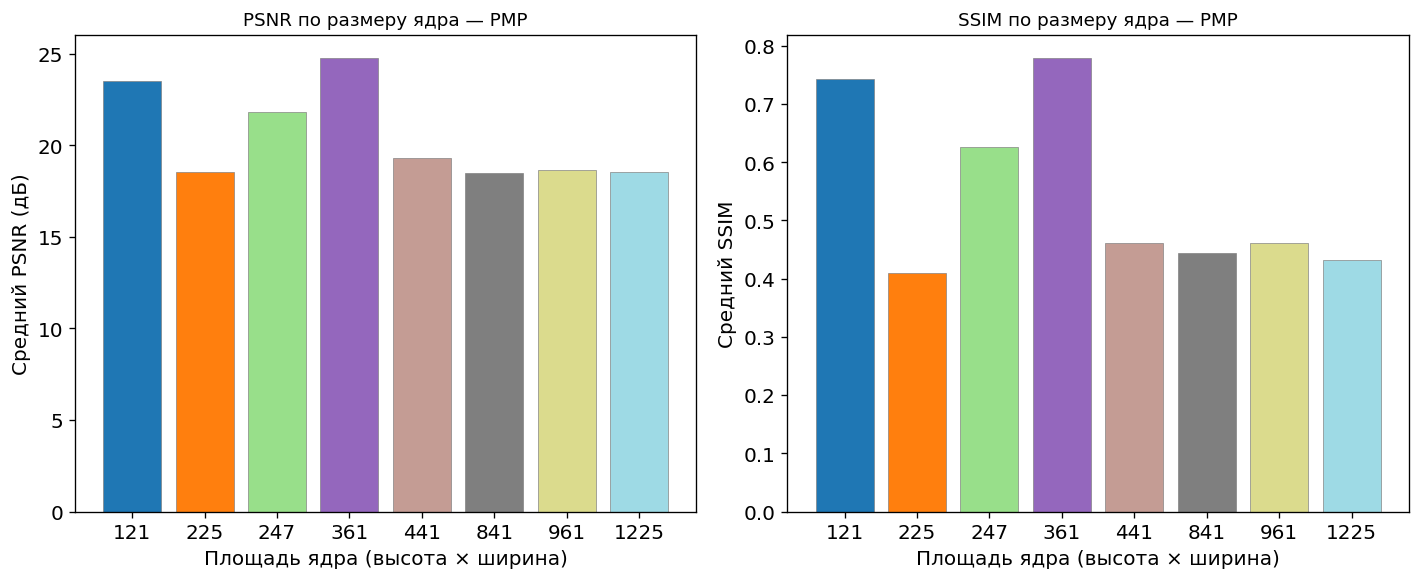

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\tex\kernel_size_dependency.tex
  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\tex\summary_table.tex


,Набор данных,Количество искаженных изображений,Размер изображения,PSNR (исх.),Среднее (PSNR),Δ PSNR,Медиана (PSNR),Максимум (PSNR),Лучший случай (PSNR),Минимум (PSNR),...,SSIM (исх.),Среднее (SSIM),Δ SSIM,Медиана (SSIM),Максимум (SSIM),Лучший случай (SSIM),Минимум (SSIM),Худший случай (SSIM),Отн. ошибки,Время (с)
0,Grid_Test,50,256x256,19.45,20.05,+0.60,19.39,27.63,drawing_defocus_pink.png,15.05,...,0.4525,0.5271,+0.0746,0.4863,0.8619,drawing_defocus_pink.png,0.2767,star_spiral_impulse.png,1.27,40.29
1,Complexity_Test,2,255x255,19.96,19.95,-0.01,19.95,20.29,barbara_hookdefocus_kernel_gaussian.png,19.61,...,0.4088,0.4966,+0.0878,0.4966,0.4982,barbara_hookdefocus_kernel_gaussian.png,0.4951,boy_hookdefocus_kernel_gaussian.png,1.21,29.28
2,ВСЕ (Суммарно),52,Различные,19.47,20.05,+0.58,19.49,27.63,drawing_defocus_pink.png,15.05,...,0.4508,0.5259,+0.0751,0.4923,0.8619,drawing_defocus_pink.png,0.2767,star_spiral_impulse.png,1.26,39.87



Общий CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\PMP\all_results_PMP.csv


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 3. Финальная сводка для одного алгоритма
# ══════════════════════════════════════════════════════════════════════════════

# Объединяем все результаты
df_all = pd.concat([r['df'] for r in ALL_DATASET_RESULTS], ignore_index=True)
print(f"Всего обработано изображений: {len(df_all)}\n")

TEX_DIR = ALG_RESULTS_DIR / "tex"
TEX_DIR.mkdir(exist_ok=True)
FIG_DIR = ALG_RESULTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ─── 9. Боксплоты PSNR/SSIM для одного метода по датасетам ──────────
vis.plot_boxplots_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 14. Сравнение 1D-профилей ядер и карт разности ──────────────────
# Создадим отдельную папку для профилей, так как их будет сохранено много
PROFILES_DIR = ALG_RESULTS_DIR / "kernel_profiles"
vis.save_kernel_profiles_and_diff(
    df_all, DIST_DIR, PROFILES_DIR, ALGORITHM_LABEL
)
print(f"Профили ядер сохранены в: {PROFILES_DIR}")

# ─── 6. Гистограмма распределения отношения ошибки ───────────────────────────
vis.plot_error_ratio_histogram_single(
    df_all['error_ratio'], ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 2. Доля успешных / отношение ошибки ─────────────────────────────────────
vis.plot_success_rate_single(
    df_all['error_ratio'], ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 3. Столбчатая диаграмма PSNR / SSIM по изображениям ─────────────────────
vis.plot_psnr_ssim_bars_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 8. Зависимость от размера ядра ──────────────────────────────────────────
vis.plot_kernel_size_dependency_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 10 & 11. Итоговая таблица (с Суммарной строкой и экстремумами) ───────────
df_summary = vis.build_summary_single(
    ALL_DATASET_RESULTS, ALGORITHM_LABEL, tex_dir=TEX_DIR
)
display(df_summary)

# Сохраняем объединённый CSV
df_all.to_csv(ALG_RESULTS_DIR / f"all_results_{ALGORITHM_LABEL}.csv", index=False)
print(f"\nОбщий CSV: {ALG_RESULTS_DIR / f'all_results_{ALGORITHM_LABEL}.csv'}")